<a href="https://colab.research.google.com/github/Jago56/Andre-Data_Analyst/blob/main/retail_sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Load the Retail Sales CSV

retail‑sales analytics project is to turn raw transaction data into clear, actionable insights that help a business understand performance and make better decisions. evaluate sales patterns, product performance, pricing behavior, and regional trends in order to help the business increase revenue, optimize inventory, and strengthen decision‑making.





In [9]:
# Load the file
df = pd.read_excel('/content/retail_sales.csv.xlsx')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 1 columns):
 #   Column                                                                                   Non-Null Count  Dtype 
---  ------                                                                                   --------------  ----- 
 0   date,store_id,product_id,product_name,category,units_sold,unit_price,total_sales,region  40 non-null     object
dtypes: object(1)
memory usage: 452.0+ bytes


In [10]:
#display the data was loaded into a single column
#with the header 'date,store_id,product_id,...'.
df.info()


# This means we need to split this single column into multiple columns.
current_single_column_name = df.columns[0]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 1 columns):
 #   Column                                                                                   Non-Null Count  Dtype 
---  ------                                                                                   --------------  ----- 
 0   date,store_id,product_id,product_name,category,units_sold,unit_price,total_sales,region  40 non-null     object
dtypes: object(1)
memory usage: 452.0+ bytes


Checking for any missing values in the dataset to understand its completeness.

In [11]:
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("No missing values found in the dataset.")
else:
    print("Missing values found in the above columns.")

,0


No missing values found in the dataset.


In [12]:
# Split the single column by comma into new columns
split_data = df[current_single_column_name].str.split(',', expand=True)

In [13]:
# The header for the split data from the original single column name
new_column_names = current_single_column_name.split(',')


In [14]:
df = split_data # Replace the original df with the split df

In [15]:
df.columns = new_column_names
# Convert numerical columns to the correct data type
df['units_sold'] = pd.to_numeric(df['units_sold'])
df['unit_price'] = pd.to_numeric(df['unit_price'])
df['total_sales'] = pd.to_numeric(df['total_sales'])

display(df.head())

,date,store_id,product_id,product_name,category,units_sold,unit_price,total_sales,region
0,2024-01-01,101,P001,AlphaPhone,Electronics,10,699,6990,East
1,2024-01-01,102,P002,SmartWatch X,Electronics,18,199,3582,South
2,2024-01-01,103,P003,Laptop Pro,Computers,6,1299,7794,West
3,2024-01-01,104,P004,Tablet Air,Electronics,14,499,6986,North
4,2024-01-02,101,P005,Headphones+,Accessories,32,149,4768,East


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          40 non-null     object
 1   store_id      40 non-null     object
 2   product_id    40 non-null     object
 3   product_name  40 non-null     object
 4   category      40 non-null     object
 5   units_sold    40 non-null     int64 
 6   unit_price    40 non-null     int64 
 7   total_sales   40 non-null     int64 
 8   region        40 non-null     object
dtypes: int64(3), object(6)
memory usage: 2.9+ KB


In [16]:
# Calculate average sales by product category
average_sales_by_category = df.groupby('category')['total_sales'].mean().reset_index()

# Display the results
display(average_sales_by_category)

,category,total_sales
0,Accessories,6872.625
1,Computers,7794.000
2,Electronics,7502.500


### Average Sales by Product Category Visualization

This bar chart visualizes the average total sales for each product category, allowing for a quick comparison of their performance.

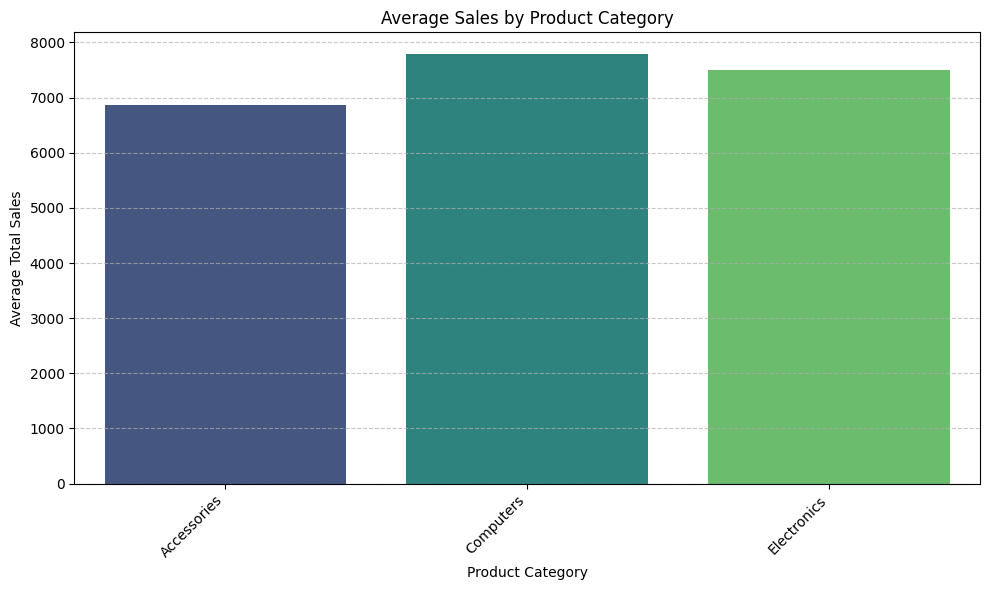

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='category', y='total_sales', data=average_sales_by_category, palette='viridis', hue='category', legend=False)
plt.title('Average Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Average Total Sales')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [17]:
average_sales_by_category = (
    df.groupby('category')['total_sales']
      .mean()
      .reset_index()
)
display(average_sales_by_category)

,category,total_sales
0,Accessories,6872.625
1,Computers,7794.000
2,Electronics,7502.500


### Total Units Sold by Region

 calculates and displays the total number of units sold for each geographical region present in the dataset.

In [ ]:
total_units_sold_by_region = df.groupby('region')['units_sold'].sum().reset_index()
display(total_units_sold_by_region)

,region,units_sold
0,East,214
1,North,209
2,South,204
3,West,230


In [20]:
total_units_sold_by_region = df.groupby('region')['units_sold'].sum().reset_index()
highest_sales_region = total_units_sold_by_region.loc[total_units_sold_by_region['units_sold'].idxmax()]
print(f"The region with the highest number of units sold is: {highest_sales_region['region']} with {highest_sales_region['units_sold']} units.")

The region with the highest number of units sold is: West with 230 units.


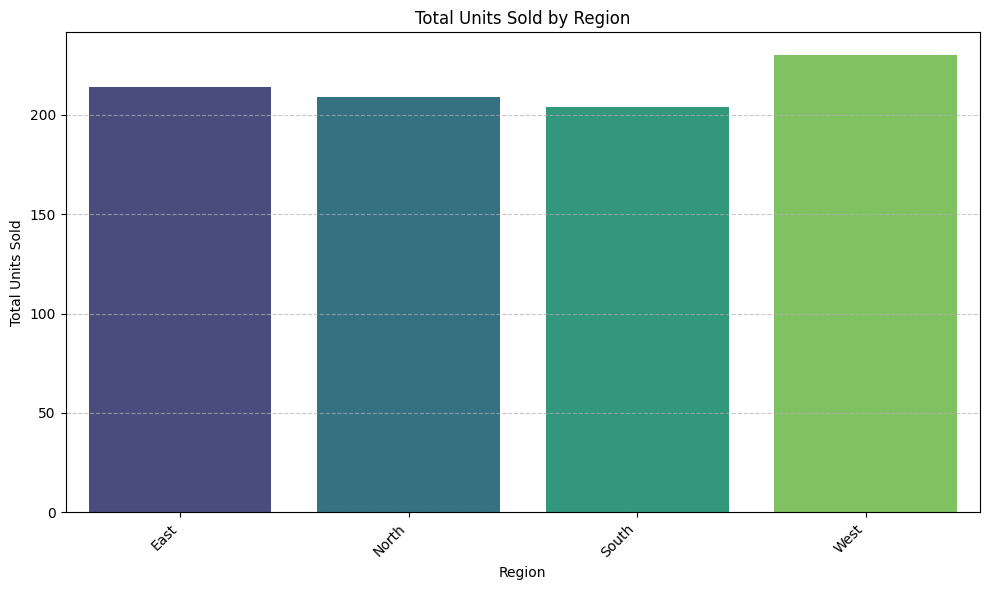

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='region', y='units_sold', data=total_units_sold_by_region, palette='viridis', hue='region', legend=False)
plt.title('Total Units Sold by Region')
plt.xlabel('Region')
plt.ylabel('Total Units Sold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()